In [1]:
!pip install lightkurve wotan astropy xgboost -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 94.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
data

In [2]:
import numpy as np
import pandas as pd
import lightkurve as lk
from wotan import flatten
from astropy.timeseries import BoxLeastSquares
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


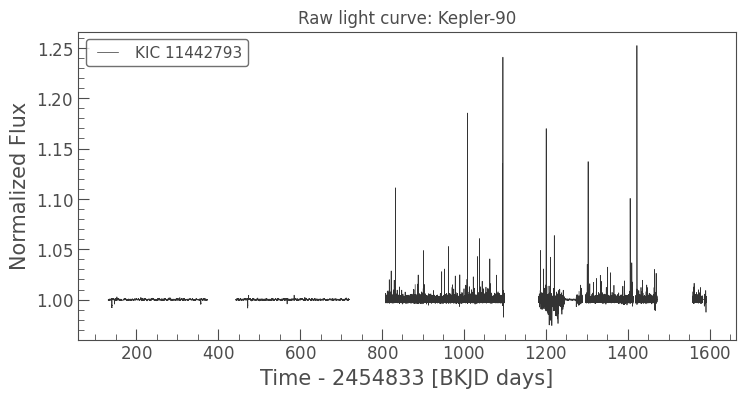

In [3]:
target_name = "Kepler-90"

search_result = lk.search_lightcurve(target_name, mission="Kepler", author="Kepler")
lc_collection = search_result.download_all()
lc = lc_collection.stitch()

lc.plot()
plt.title(f"Raw light curve: {target_name}")
plt.show()

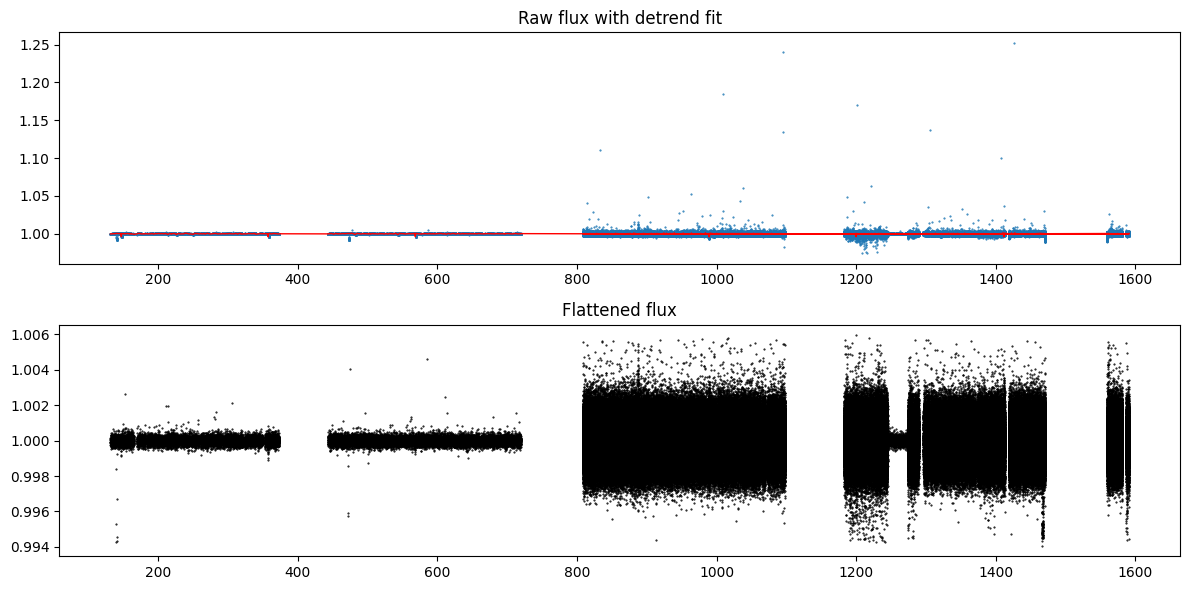

In [4]:
def preprocess_lightcurve(lc, window_length=0.5, sigma=5):
    """
    lc: lightkurve LightCurve object
    window_length: wotan biweight window in days
    sigma: sigma-clip threshold
    """
    lc_clean = lc.remove_nans()
    time = lc_clean.time.value
    flux = lc_clean.flux.value

    # sigma clip first
    flux_clipped = np.copy(flux)
    med = np.nanmedian(flux_clipped)
    std = np.nanstd(flux_clipped)
    mask = np.abs(flux_clipped - med) < sigma * std
    time_clipped = time[mask]
    flux_clipped = flux_clipped[mask]

    # detrend with wotan biweight
    flux_flat, trend = flatten(
        time_clipped, flux_clipped,
        window_length=window_length,
        method="biweight",
        return_trend=True
    )

    return time_clipped, flux_flat, trend

time_clean, flux_flat, trend = preprocess_lightcurve(lc)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(time_clean, lc.flux.value[:len(time_clean)], '.', ms=1)
axes[0].plot(time_clean, trend, 'r-', lw=1)
axes[0].set_title("Raw flux with detrend fit")

axes[1].plot(time_clean, flux_flat, '.', ms=1, color='black')
axes[1].set_title("Flattened flux")
plt.tight_layout()
plt.show()

In [ ]:
print(len(time_clean))
print(time_clean.max() - time_clean.min(), "days baseline")

In [ ]:
def run_bls(time, flux, min_period=0.5, max_period=50, duration_grid=None):
    if duration_grid is None:
        # durations must stay well below min_period
        duration_grid = np.linspace(0.02, 0.3 * min_period, 10)

    bls = BoxLeastSquares(time, flux)
    periodogram = bls.autopower(duration_grid, minimum_period=min_period, maximum_period=max_period)

    best_idx = np.argmax(periodogram.power)
    result = {
        "period": periodogram.period[best_idx],
        "t0": periodogram.transit_time[best_idx],
        "duration": periodogram.duration[best_idx],
        "power": periodogram.power[best_idx],
        "depth": periodogram.depth[best_idx],
    }
    return bls, periodogram, result

bls, periodogram, best = run_bls(time_clean, flux_flat)
print(best)

plt.figure(figsize=(10, 4))
plt.plot(periodogram.period, periodogram.power)
plt.axvline(best["period"], color='r', linestyle='--', label=f"Best period: {best['period']:.3f} d")
plt.xlabel("Period (days)")
plt.ylabel("BLS power")
plt.legend()
plt.show()

In [ ]:
def phase_fold(time, flux, period, t0):
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    order = np.argsort(phase)
    return phase[order], flux[order]

phase, flux_folded = phase_fold(time_clean, flux_flat, best["period"], best["t0"])

plt.figure(figsize=(10, 5))
plt.plot(phase, flux_folded, '.', ms=2, color='black', alpha=0.5)
plt.xlim(-0.1, 0.1)
plt.xlabel("Phase")
plt.ylabel("Normalized flux")
plt.title(f"Phase-folded light curve, period={best['period']:.3f} d")
plt.show()

In [ ]:
def iterative_bls_search(time, flux, n_planets=3, min_period=0.5, max_period=50):
    candidates = []
    flux_residual = np.copy(flux)
    duration_grid = np.linspace(0.02, 0.3 * min_period, 10)

    for i in range(n_planets):
        bls = BoxLeastSquares(time, flux_residual)
        pg = bls.autopower(duration_grid, minimum_period=min_period, maximum_period=max_period)
        best_idx = np.argmax(pg.power)

        period = pg.period[best_idx]
        t0 = pg.transit_time[best_idx]
        duration = pg.duration[best_idx]
        power = pg.power[best_idx]
        depth = pg.depth[best_idx]

        candidates.append({
            "planet_number": i + 1,
            "period": period,
            "t0": t0,
            "duration": duration,
            "power": power,
            "depth": depth,
        })

        mask = bls.transit_mask(time, period, duration, t0)
        flux_residual[mask] = np.nanmedian(flux_residual)

    return pd.DataFrame(candidates)

candidates_df = iterative_bls_search(time_clean, flux_flat, n_planets=3)
candidates_df

In [ ]:
def extract_features(time, flux, period, t0, duration):
    """
    Extract physically-motivated features from a BLS candidate for classification.
    """
    features = {}

    # basic BLS outputs
    features["period"] = period
    features["duration"] = duration

    # phase fold at this candidate's period
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    in_transit = np.abs(phase) < (duration / period) / 2

    if in_transit.sum() < 3:
        # not enough points to characterize — return NaNs, will get filtered later
        features["depth"] = np.nan
        features["snr"] = np.nan
        features["odd_even_depth_diff"] = np.nan
        features["secondary_eclipse_depth"] = np.nan
        features["num_transits_observed"] = 0
        return features

    out_of_transit_flux = flux[~in_transit]
    in_transit_flux = flux[in_transit]

    baseline = np.nanmedian(out_of_transit_flux)
    depth = baseline - np.nanmedian(in_transit_flux)
    noise = np.nanstd(out_of_transit_flux)

    features["depth"] = depth
    features["snr"] = depth / noise if noise > 0 else 0

    # odd/even transit check
    transit_number = np.floor((time - t0) / period + 0.5)
    odd_mask = in_transit & (transit_number % 2 == 1)
    even_mask = in_transit & (transit_number % 2 == 0)

    if odd_mask.sum() > 1 and even_mask.sum() > 1:
        odd_depth = baseline - np.nanmedian(flux[odd_mask])
        even_depth = baseline - np.nanmedian(flux[even_mask])
        features["odd_even_depth_diff"] = abs(odd_depth - even_depth)
    else:
        features["odd_even_depth_diff"] = np.nan

    # secondary eclipse check (phase ~0.5)
    secondary_mask = np.abs(np.abs(phase) - 0.5) < (duration / period) / 2
    if secondary_mask.sum() > 2:
        secondary_flux = np.nanmedian(flux[secondary_mask])
        features["secondary_eclipse_depth"] = baseline - secondary_flux
    else:
        features["secondary_eclipse_depth"] = np.nan

    features["num_transits_observed"] = len(np.unique(transit_number[in_transit]))

    return features

# test on the best candidate from Cell 5
feat = extract_features(time_clean, flux_flat, best["period"], best["t0"], best["duration"])
feat

In [ ]:
koi_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv"
koi_df = pd.read_csv(koi_url)

print(koi_df.shape)
koi_df[["kepoi_name", "koi_disposition", "koi_period", "koi_duration", "koi_depth", "koi_model_snr"]].head()

In [ ]:
def prepare_koi_training_data(koi_df):
    df = koi_df.copy()

    # collapse to binary label: CONFIRMED + CANDIDATE = 1, FALSE POSITIVE = 0
    df = df[df["koi_disposition"].isin(["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"])]
    df["label"] = (df["koi_disposition"] != "FALSE POSITIVE").astype(int)

    feature_cols = [
        "koi_period", "koi_duration", "koi_depth", "koi_model_snr",
        "koi_prad", "koi_impact", "koi_num_transits"
    ]

    df = df.dropna(subset=feature_cols + ["label"])

    X = df[feature_cols]
    y = df["label"]

    return X, y, df

X, y, koi_clean = prepare_koi_training_data(koi_df)
print(X.shape, y.value_counts())

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

gbt_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

gbt_model.fit(X_train, y_train)

y_pred = gbt_model.predict(X_test)
y_proba = gbt_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

In [ ]:
importances = pd.Series(gbt_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("GBT feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()